# Heart Disease Prediction - EDA & Machine Learning Model

Classic **Cleveland Heart Disease** dataset (1025 records, 13 features). Full pipeline: EDA -> cleaning -> preprocessing -> 9-model comparison -> hyperparameter tuning -> cross-validation -> evaluation -> save.

**Features (full names):**
- **Age (years)**: `age`
- **Sex**: `sex` (1 = male, 0 = female)
- **Chest Pain Type**: `cp` (0-3)
- **Resting Blood Pressure (mm Hg)**: `trestbps`
- **Serum Cholesterol (mg/dL)**: `chol`
- **Fasting Blood Sugar > 120 (mg/dL)**: `fbs`
- **Resting ECG Results**: `restecg` (0,1,2)
- **Max Heart Rate Achieved**: `thalach`
- **Exercise-Induced Angina**: `exang`
- **ST Depression (Oldpeak)**: `oldpeak`
- **Peak Exercise ST Slope**: `slope` (0-2)
- **Major Vessels (Fluoroscopy)**: `ca` (0-3)
- **Thalassemia (Thal)**: `thal` (0 = normal; 1 = fixed defect; 2 = reversible defect)
- **target**: `target` (1 = disease, 0 = no disease)

---

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, matthews_corrcoef
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib
import os

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Data

In [2]:
DATA_PATH = 'heart.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Column name mapping

The dataset uses short codes. Below is the full name of every column, and we rename them throughout the analysis:

In [3]:
short_to_full = {
    'age':      'Age (years)',
    'sex':      'Sex',
    'cp':       'Chest Pain Type',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol':     'Serum Cholesterol (mg/dL)',
    'fbs':      'Fasting Blood Sugar > 120 (mg/dL)',
    'restecg':  'Resting ECG Results',
    'thalach':  'Max Heart Rate Achieved',
    'exang':    'Exercise-Induced Angina',
    'oldpeak':  'ST Depression (Oldpeak)',
    'slope':    'Peak Exercise ST Slope',
    'ca':       'Major Vessels (Fluoroscopy)',
    'thal':     'Thalassemia (Thal)',
    'target':   'target',
}

full_desc = {
    'Age (years)': 'Age of the patient in years',
    'Sex': 'Gender (1 = male, 0 = female)',
    'Chest Pain Type': 'Chest pain type (0-3)',
    'Resting Blood Pressure (mm Hg)': 'Resting blood pressure in mm Hg',
    'Serum Cholesterol (mg/dL)': 'Serum cholesterol in mg/dL',
    'Fasting Blood Sugar > 120 (mg/dL)': 'Fasting blood sugar > 120 mg/dL (1 = true, 0 = false)',
    'Resting ECG Results': 'Resting electrocardiographic results (0, 1, 2)',
    'Max Heart Rate Achieved': 'Maximum heart rate achieved during exercise',
    'Exercise-Induced Angina': 'Exercise-induced angina (1 = yes, 0 = no)',
    'ST Depression (Oldpeak)': 'ST depression induced by exercise relative to rest',
    'Peak Exercise ST Slope': 'Slope of the peak exercise ST segment (0-2)',
    'Major Vessels (Fluoroscopy)': 'Number of major vessels (0-3) colored by fluoroscopy',
    'Thalassemia (Thal)': 'Thalassemia: 0 = normal; 1 = fixed defect; 2 = reversible defect',
    'target': 'Heart disease target (1 = disease, 0 = no disease)',
}

name_map = pd.DataFrame(
    {'Short Name': short_to_full.keys(),
     'Full Name': short_to_full.values(),
     'Description': [full_desc[v] for v in short_to_full.values()]}
)
df = df.rename(columns=short_to_full)
print('Columns renamed to full descriptive names.')
print()
name_map

Columns renamed to full descriptive names.



,Short Name,Full Name,Description
0,age,Age (years),Age of the patient in years
1,sex,Sex,"Gender (1 = male, 0 = female)"
2,cp,Chest Pain Type,Chest pain type (0-3)
3,trestbps,Resting Blood Pressure (mm Hg),Resting blood pressure in mm Hg
4,chol,Serum Cholesterol (mg/dL),Serum cholesterol in mg/dL
5,fbs,Fasting Blood Sugar > 120 (mg/dL),"Fasting blood sugar > 120 mg/dL (1 = true, 0 =..."
6,restecg,Resting ECG Results,"Resting electrocardiographic results (0, 1, 2)"
7,thalach,Max Heart Rate Achieved,Maximum heart rate achieved during exercise
8,exang,Exercise-Induced Angina,"Exercise-induced angina (1 = yes, 0 = no)"
9,oldpeak,ST Depression (Oldpeak),ST depression induced by exercise relative to ...


## 3. Data Overview & Quality Check

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age (years)                        1025 non-null   int64  
 1   Sex                                1025 non-null   int64  
 2   Chest Pain Type                    1025 non-null   int64  
 3   Resting Blood Pressure (mm Hg)     1025 non-null   int64  
 4   Serum Cholesterol (mg/dL)          1025 non-null   int64  
 5   Fasting Blood Sugar > 120 (mg/dL)  1025 non-null   int64  
 6   Resting ECG Results                1025 non-null   int64  
 7   Max Heart Rate Achieved            1025 non-null   int64  
 8   Exercise-Induced Angina            1025 non-null   int64  
 9   ST Depression (Oldpeak)            1025 non-null   float64
 10  Peak Exercise ST Slope             1025 non-null   int64  
 11  Major Vessels (Fluoroscopy)        1025 non-null   int64  
 12  Tha

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age (years),1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
Sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
Chest Pain Type,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
Resting Blood Pressure (mm Hg),1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
Serum Cholesterol (mg/dL),1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
Fasting Blood Sugar > 120 (mg/dL),1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
Resting ECG Results,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
Max Heart Rate Achieved,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
Exercise-Induced Angina,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
ST Depression (Oldpeak),1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [6]:
print('Missing values:')
df.isnull().sum().to_frame('Missing')

Missing values:


,Missing
Age (years),0
Sex,0
Chest Pain Type,0
Resting Blood Pressure (mm Hg),0
Serum Cholesterol (mg/dL),0
Fasting Blood Sugar > 120 (mg/dL),0
Resting ECG Results,0
Max Heart Rate Achieved,0
Exercise-Induced Angina,0
ST Depression (Oldpeak),0


In [7]:
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\nUnique values per column:')
for c in df.columns:
    print(f'  {c}: {sorted(df[c].unique())}')

Duplicate rows: 723

Unique values per column:
  Age (years): [np.int64(29), np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77)]
  Sex: [np.int64(0), np.int64(1)]
  Chest Pain Type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Resting Blood Pressure (mm Hg): [np.int64(94), np.int64(100), np.int64(101), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(110), np.int64(112), np.int64(114), np.int64(115), np.int64(117), np.int64(118), np.int64(120)

### Observed data-quality issues
- **723 duplicate rows** (known artifact of the 1025-row Cleveland version) -> drop them.
- `Major Vessels (Fluoroscopy)` (`ca`) is valid **0-3** but has a few invalid `4` values -> drop those rows.
- Target is well balanced (roughly 50/50).
- No missing values.

In [8]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
df = df[df['Major Vessels (Fluoroscopy)'] <= 3].reset_index(drop=True)
print(f'Kept {len(df)} of {rows_before} rows (dropped {rows_before - len(df)})')
print(df['target'].value_counts())

Kept 298 of 1025 rows (dropped 727)
target
1    161
0    137
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target distribution

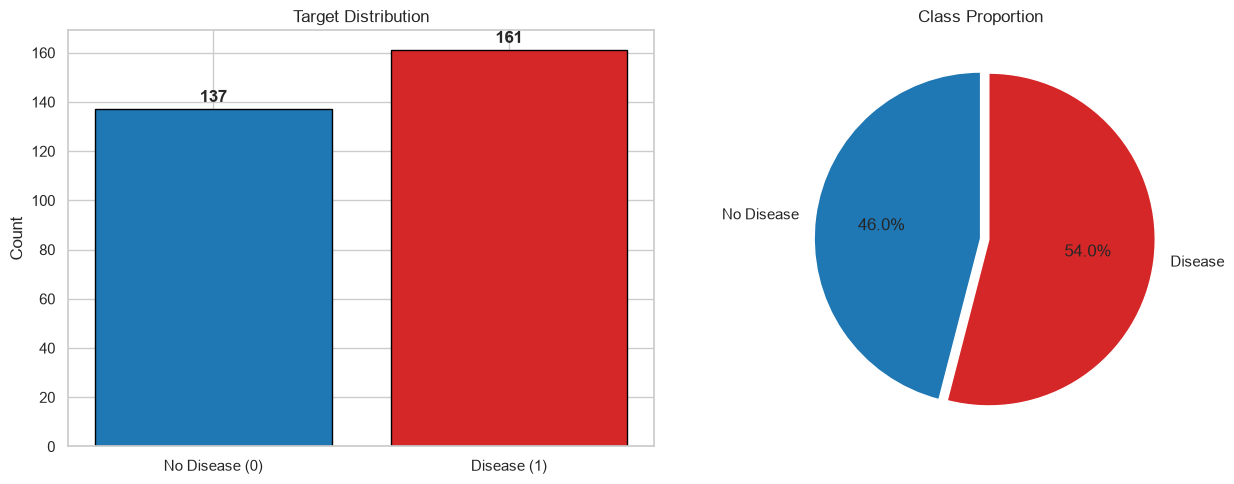

In [9]:
counts = df['target'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#1f77b4', '#d62728'], edgecolor='black')
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Disease', 'Disease'], colors=['#1f77b4', '#d62728'],
            autopct='%1.1f%%', startangle=90, explode=[0, 0.05])
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()

### 4.2 Correlation heatmap

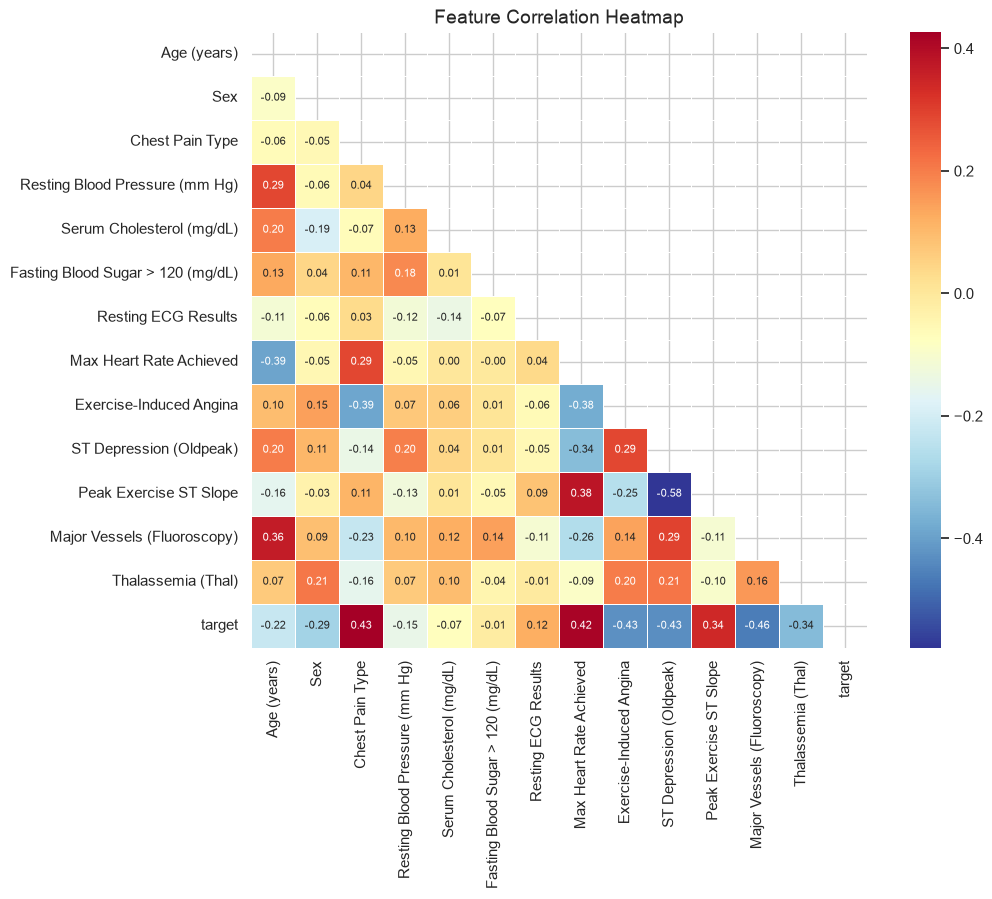

,Correlation with target
Chest Pain Type,0.427151
Max Heart Rate Achieved,0.417844
Peak Exercise ST Slope,0.341267
Resting ECG Results,0.124487
Fasting Blood Sugar > 120 (mg/dL),-0.014649
Serum Cholesterol (mg/dL),-0.074977
Resting Blood Pressure (mm Hg),-0.148283
Age (years),-0.224151
Sex,-0.290113
Thalassemia (Thal),-0.343203


In [10]:
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', linewidths=0.7, square=True,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

corr_target = corr['target'].drop('target').sort_values(ascending=False)
corr_target.to_frame('Correlation with target')

### 4.3 Distributions by target (continuous features)

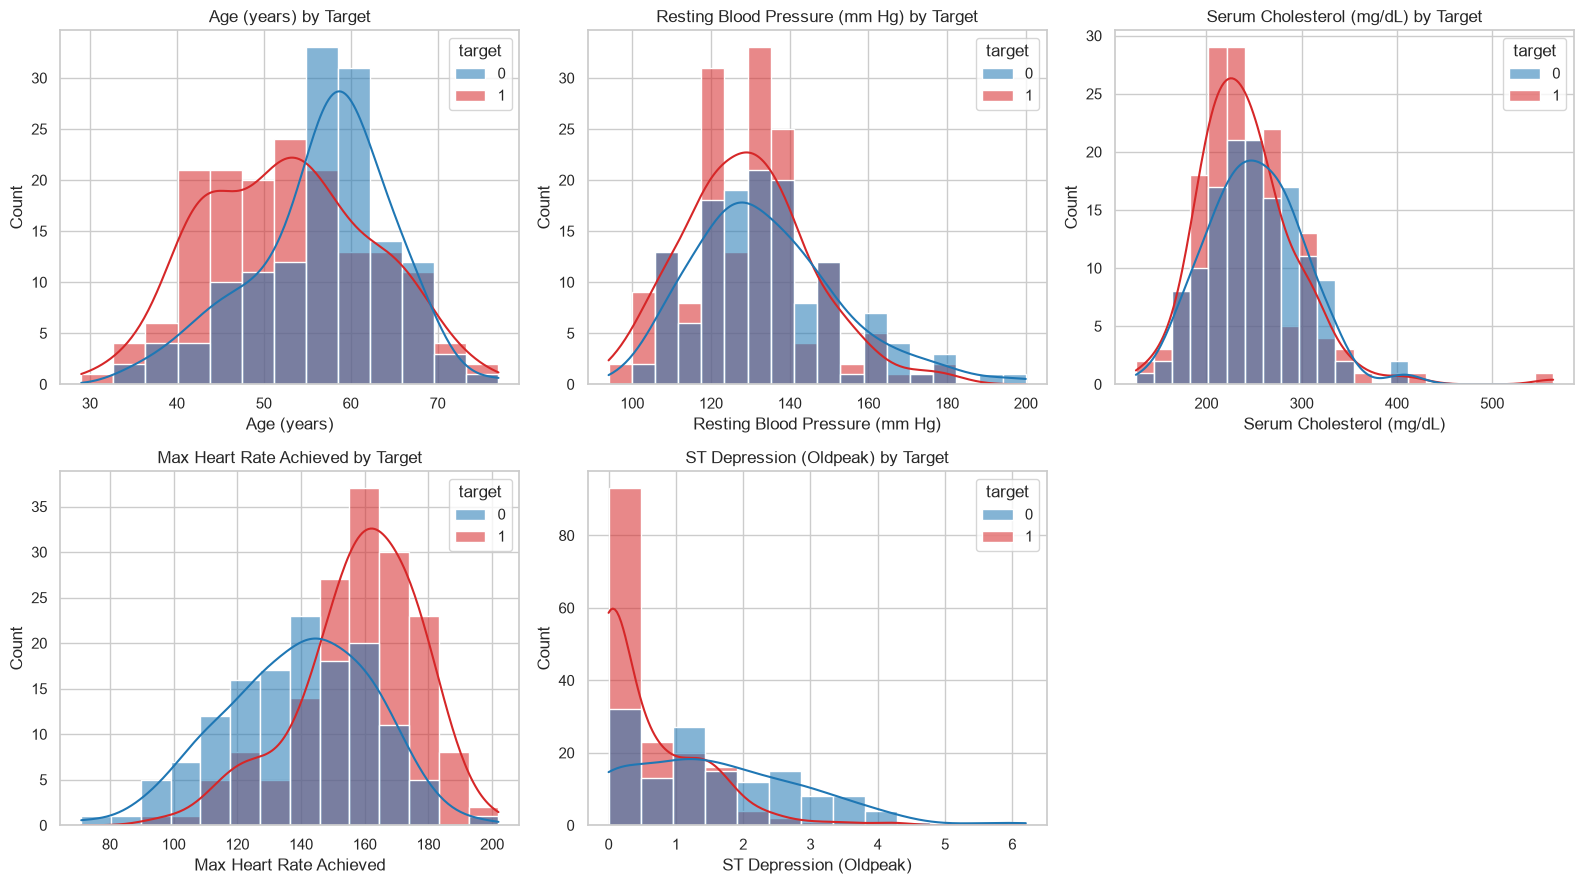

In [11]:
cont_cols = ['Age (years)', 'Resting Blood Pressure (mm Hg)', 'Serum Cholesterol (mg/dL)',
             'Max Heart Rate Achieved', 'ST Depression (Oldpeak)']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i], palette=['#1f77b4', '#d62728'], alpha=0.55)
    axes[i].set_title(f'{col} by Target')

axes[5].axis('off')
plt.tight_layout()
plt.show()

### 4.4 Boxplots of continuous features by target

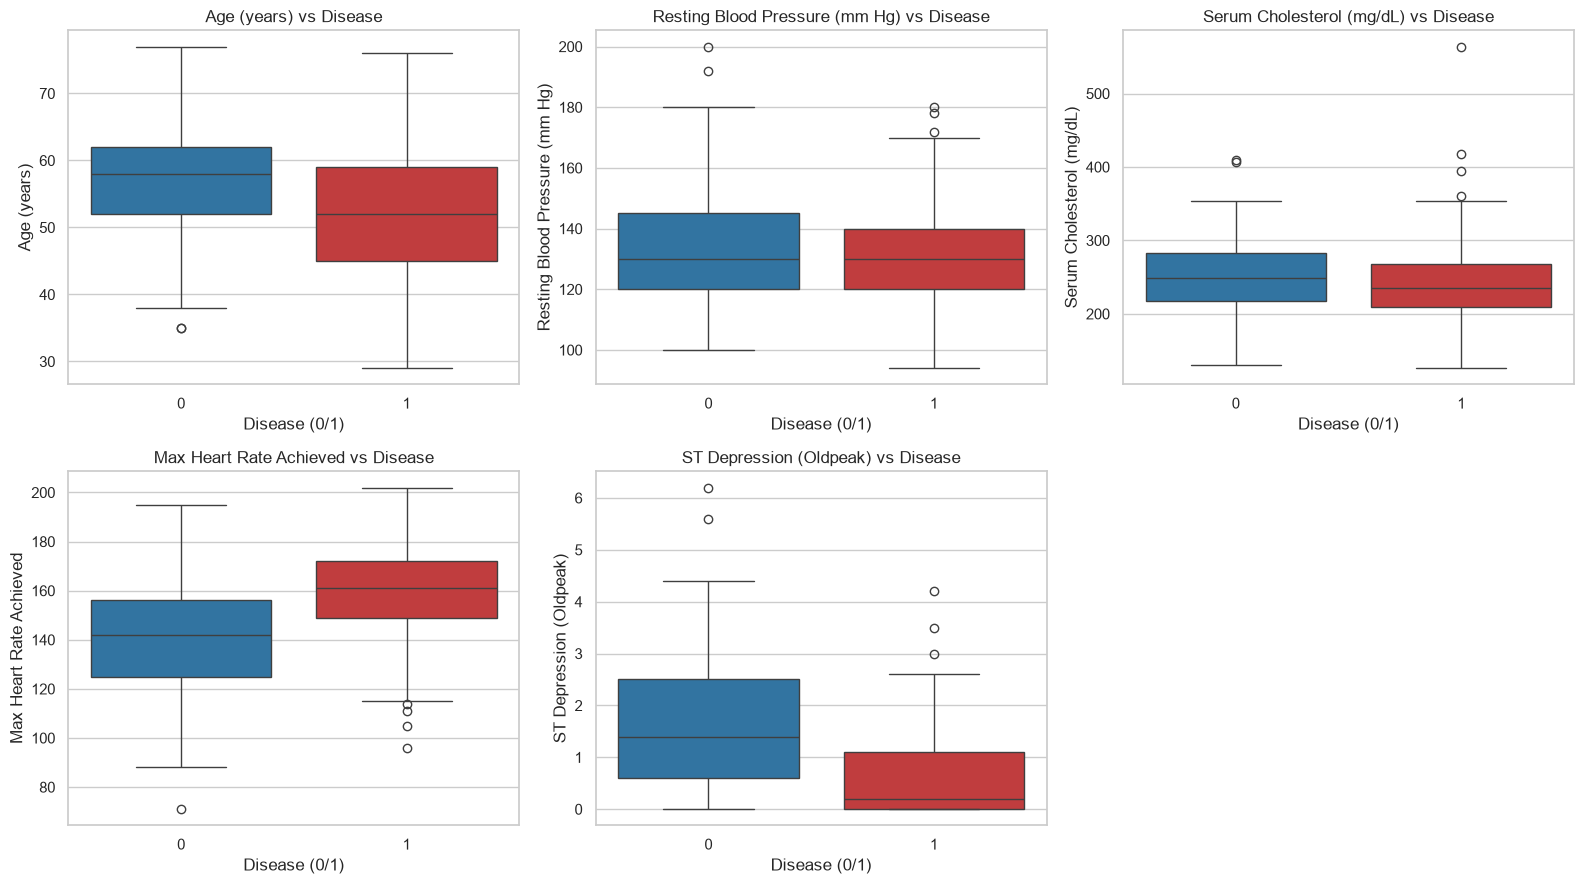

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cont_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['#1f77b4', '#d62728'])
    axes[i].set_title(f'{col} vs Disease')
    axes[i].set_xlabel('Disease (0/1)')
axes[5].axis('off')
plt.tight_layout()
plt.show()

### 4.5 Categorical features vs target

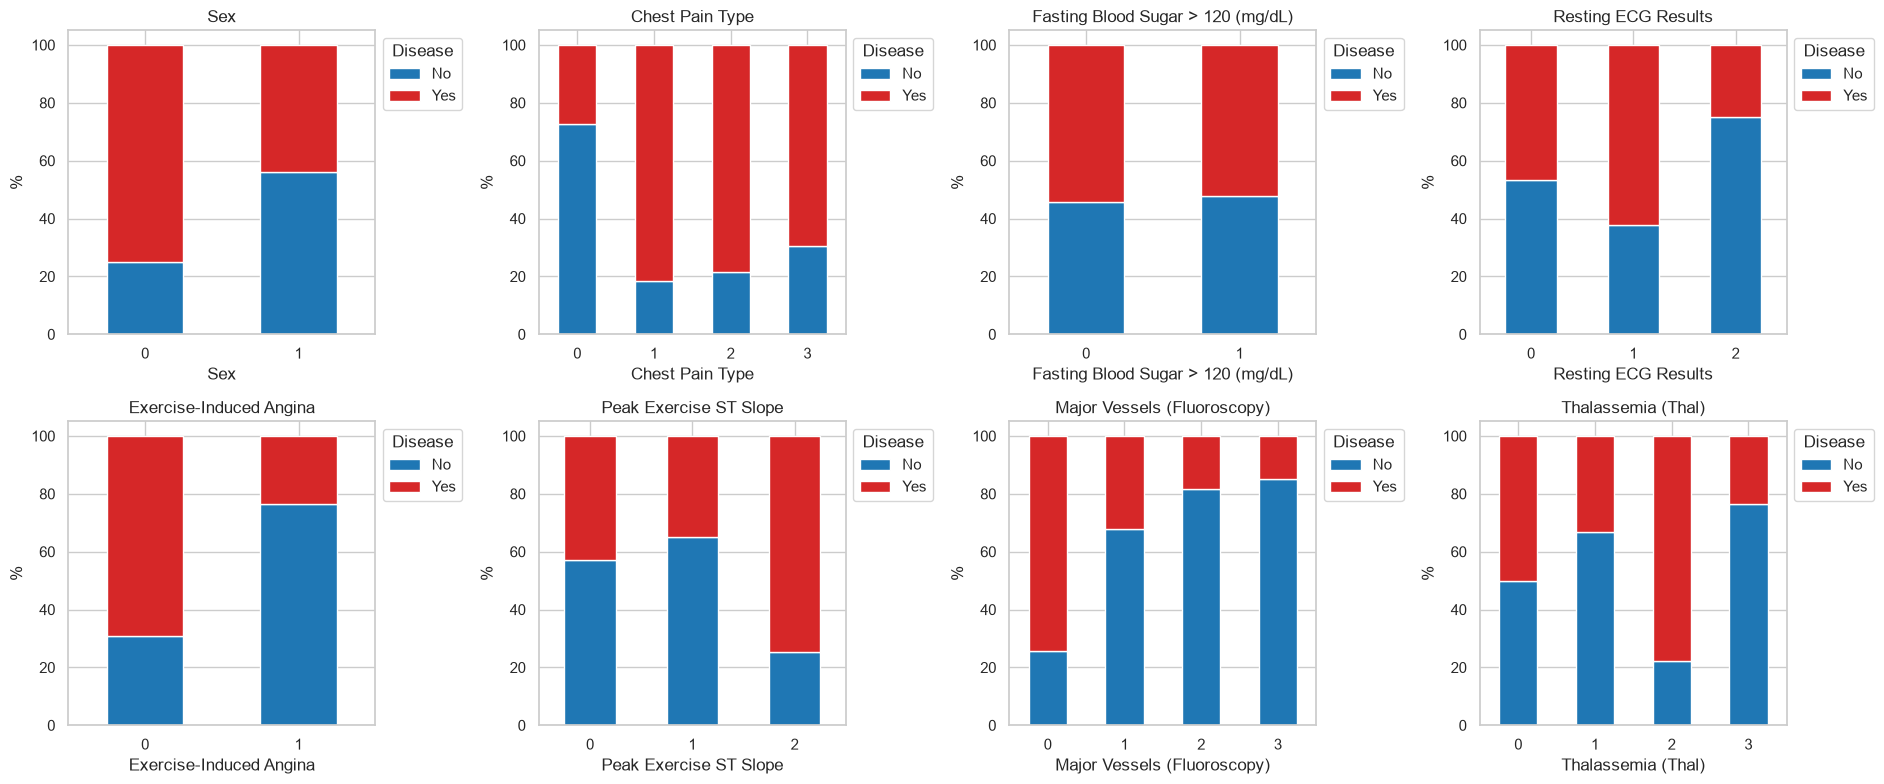

In [13]:
cat_cols = ['Sex', 'Chest Pain Type', 'Fasting Blood Sugar > 120 (mg/dL)', 'Resting ECG Results',
            'Exercise-Induced Angina', 'Peak Exercise ST Slope', 'Major Vessels (Fluoroscopy)', 'Thalassemia (Thal)']
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ctab = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ctab.plot(kind='bar', stacked=True, ax=axes[i], color=['#1f77b4', '#d62728'], legend=False)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No', 'Yes'], title='Disease', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [14]:
cat_pct = []
for c in cat_cols:
    s = (pd.crosstab(df[c], df['target'], normalize='index')[1] * 100).round(1).rename(c)
    cat_pct.append(s)
pd.DataFrame(cat_pct).T.rename_axis('Category')

,Sex,Chest Pain Type,Fasting Blood Sugar > 120 (mg/dL),Resting ECG Results,Exercise-Induced Angina,Peak Exercise ST Slope,Major Vessels (Fluoroscopy),Thalassemia (Thal)
Category,,,,,,,,
0,75.0,27.5,54.3,46.6,69.0,42.9,74.3,50.0
1,44.1,81.6,52.3,62.2,23.5,34.8,32.3,33.3
2,NaN,78.6,NaN,25.0,NaN,74.8,18.4,77.9
3,NaN,69.6,NaN,NaN,NaN,NaN,15.0,23.5


### 4.6 Heart disease rate vs age group & sex

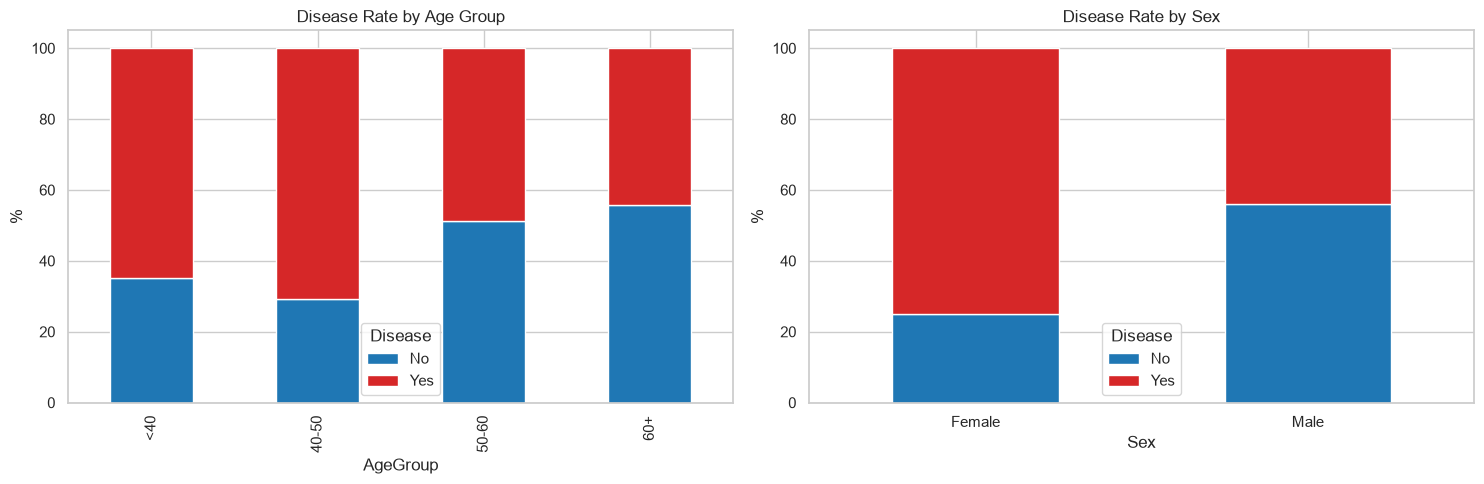

In [15]:
df['AgeGroup'] = pd.cut(df['Age (years)'], bins=[20, 40, 50, 60, 80], labels=['<40', '40-50', '50-60', '60+'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
piv1 = pd.crosstab(df['AgeGroup'], df['target'], normalize='index') * 100
piv1.plot(kind='bar', stacked=True, ax=axes[0], color=['#1f77b4', '#d62728'])
axes[0].set_title('Disease Rate by Age Group'); axes[0].set_ylabel('%'); axes[0].legend(['No', 'Yes'], title='Disease')

piv2 = pd.crosstab(df['Sex'], df['target'], normalize='index') * 100
piv2.plot(kind='bar', stacked=True, ax=axes[1], color=['#1f77b4', '#d62728'])
axes[1].set_title('Disease Rate by Sex'); axes[1].set_ylabel('%'); axes[1].legend(['No', 'Yes'], title='Disease')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
plt.tight_layout()
plt.show()

df.drop('AgeGroup', axis=1, inplace=True)

### EDA Key Insights
- `Chest Pain Type`, `Max Heart Rate Achieved`, `ST Depression (Oldpeak)`, `Exercise-Induced Angina`, `Peak Exercise ST Slope`, `Major Vessels (Fluoroscopy)` and `Thalassemia (Thal)` show the strongest separation.
- Disease risk rises with age; men show higher disease rates in this sample.
- Features are mostly independent (low multicollinearity).

## 5. Preprocessing Pipeline

All features are numeric codes, so we use a **ColumnTransformer**:
- **Continuous** (`Age (years)`, `Resting Blood Pressure (mm Hg)`, `Serum Cholesterol (mg/dL)`, `Max Heart Rate Achieved`, `ST Depression (Oldpeak)`) -> StandardScaler.
- **Binary flags** (`Sex`, `Fasting Blood Sugar > 120 (mg/dL)`, `Exercise-Induced Angina`) -> passed through as-is.
- **Multi-category** (`Chest Pain Type`, `Resting ECG Results`, `Peak Exercise ST Slope`, `Major Vessels (Fluoroscopy)`, `Thalassemia (Thal)`) -> OneHotEncoder (avoids imposing false ordering).

In [16]:
cont_cols = ['Age (years)', 'Resting Blood Pressure (mm Hg)', 'Serum Cholesterol (mg/dL)',
             'Max Heart Rate Achieved', 'ST Depression (Oldpeak)']
binary_cols = ['Sex', 'Fasting Blood Sugar > 120 (mg/dL)', 'Exercise-Induced Angina']
cat_cols = ['Chest Pain Type', 'Resting ECG Results', 'Peak Exercise ST Slope',
            'Major Vessels (Fluoroscopy)', 'Thalassemia (Thal)']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), cont_cols),
    ('bin', 'passthrough', binary_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

X = df.drop('target', axis=1)
y = df['target']

X_transformed = preprocessor.fit_transform(X)
print(f'Preprocessed feature matrix shape: {X_transformed.shape}')
print(f'Feature names: {preprocessor.get_feature_names_out()}')

Preprocessed feature matrix shape: (298, 26)
Feature names: ['num__Age (years)' 'num__Resting Blood Pressure (mm Hg)'
 'num__Serum Cholesterol (mg/dL)' 'num__Max Heart Rate Achieved'
 'num__ST Depression (Oldpeak)' 'bin__Sex'
 'bin__Fasting Blood Sugar > 120 (mg/dL)' 'bin__Exercise-Induced Angina'
 'cat__Chest Pain Type_0' 'cat__Chest Pain Type_1'
 'cat__Chest Pain Type_2' 'cat__Chest Pain Type_3'
 'cat__Resting ECG Results_0' 'cat__Resting ECG Results_1'
 'cat__Resting ECG Results_2' 'cat__Peak Exercise ST Slope_0'
 'cat__Peak Exercise ST Slope_1' 'cat__Peak Exercise ST Slope_2'
 'cat__Major Vessels (Fluoroscopy)_0' 'cat__Major Vessels (Fluoroscopy)_1'
 'cat__Major Vessels (Fluoroscopy)_2' 'cat__Major Vessels (Fluoroscopy)_3'
 'cat__Thalassemia (Thal)_0' 'cat__Thalassemia (Thal)_1'
 'cat__Thalassemia (Thal)_2' 'cat__Thalassemia (Thal)_3']


## 6. Train / Test Split (stratified)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}')

Training: 238 | Test: 60
Train positive rate: 0.542 | Test positive rate: 0.533


## 7. Model Comparison (Multiple Algorithms)

In [18]:
def make_pipeline(clf):
    return Pipeline([
        ('preproc', preprocessor),
        ('clf', clf),
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

results = []
for name, clf in models.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'MCC': matthews_corrcoef(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC,MCC
0,Logistic Regression,0.8667,0.8529,0.9062,0.8788,0.9141,0.7326
1,Support Vector Machine,0.8500,0.8286,0.9062,0.8657,0.9029,0.7002
2,Random Forest,0.8500,0.8108,0.9375,0.8696,0.8951,0.7054
3,XGBoost,0.8500,0.8485,0.8750,0.8615,0.8839,0.6984
4,K-Nearest Neighbors,0.8167,0.8000,0.8750,0.8358,0.8806,0.6325
5,LightGBM,0.8000,0.8333,0.7812,0.8065,0.8772,0.6013
6,Extra Trees,0.8500,0.8108,0.9375,0.8696,0.8750,0.7054
7,Gradient Boosting,0.7667,0.7647,0.8125,0.7879,0.8717,0.5303
8,Decision Tree,0.7500,0.7576,0.7812,0.7692,0.7634,0.4969


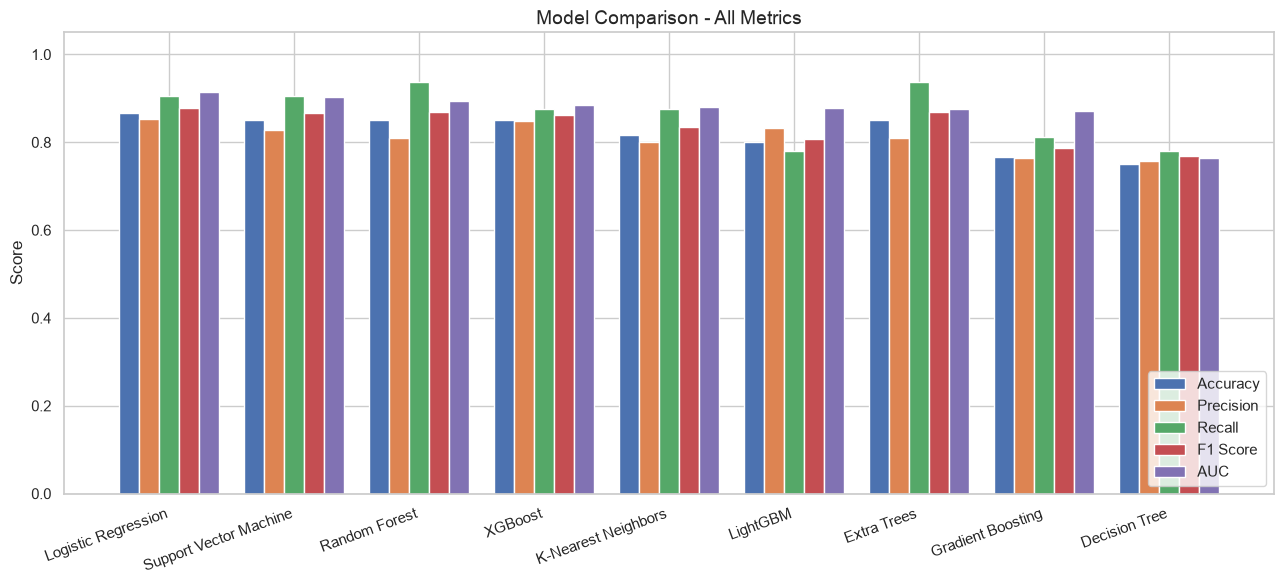

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
width = 0.8 / len(metrics_cols)
x = np.arange(len(results_df))

for i, metric in enumerate(metrics_cols):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * (len(metrics_cols) - 1) / 2)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Score'); ax.set_title('Model Comparison - All Metrics', fontsize=14)
ax.legend(loc='lower right'); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning with GridSearchCV (Stratified K-Fold)

In [20]:
best_name = results_df.iloc[0]['Model']
print(f'Tuning the top performer: {best_name}')

grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__solver': ['liblinear', 'lbfgs'],
    },
    'K-Nearest Neighbors': {
        'clf__n_neighbors': [5, 7, 9, 11, 15],
        'clf__weights': ['uniform', 'distance'],
        'clf__p': [1, 2],
    },
    'Support Vector Machine': {
        'clf__C': [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 0.01, 0.1],
        'clf__kernel': ['rbf', 'poly'],
    },
    'Decision Tree': {
        'clf__max_depth': [4, 6, 8, 10, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__criterion': ['gini', 'entropy'],
    },
    'Random Forest': {
        'clf__n_estimators': [100, 300, 500],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2'],
    },
    'Extra Trees': {
        'clf__n_estimators': [100, 300, 500],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [3, 5],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.7, 0.9],
    },
    'XGBoost': {
        'clf__n_estimators': [150, 300, 500],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.7, 0.9],
        'clf__colsample_bytree': [0.7, 0.9],
    },
    'LightGBM': {
        'clf__n_estimators': [150, 300, 500],
        'clf__num_leaves': [31, 63, 127],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.7, 0.9],
    },
}

pipe = make_pipeline(models[best_name])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, grids[best_name], cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f'\nBest Parameters: {grid.best_params_}')
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

Tuning the top performer: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits



Best Parameters: {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9166


## 9. Final Model Evaluation on the Held-out Test Set

In [21]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'MCC': matthews_corrcoef(y_test, y_pred),
}
final_metrics_df = pd.DataFrame(final_metrics, index=[f'Best Model ({best_name})']).T
final_metrics_df.round(4)

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.88      0.82      0.85        28
     Disease       0.85      0.91      0.88        32

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



,Best Model (Logistic Regression)
Accuracy,0.8667
Precision,0.8529
Recall,0.9062
F1 Score,0.8788
ROC-AUC,0.9230
MCC,0.7326


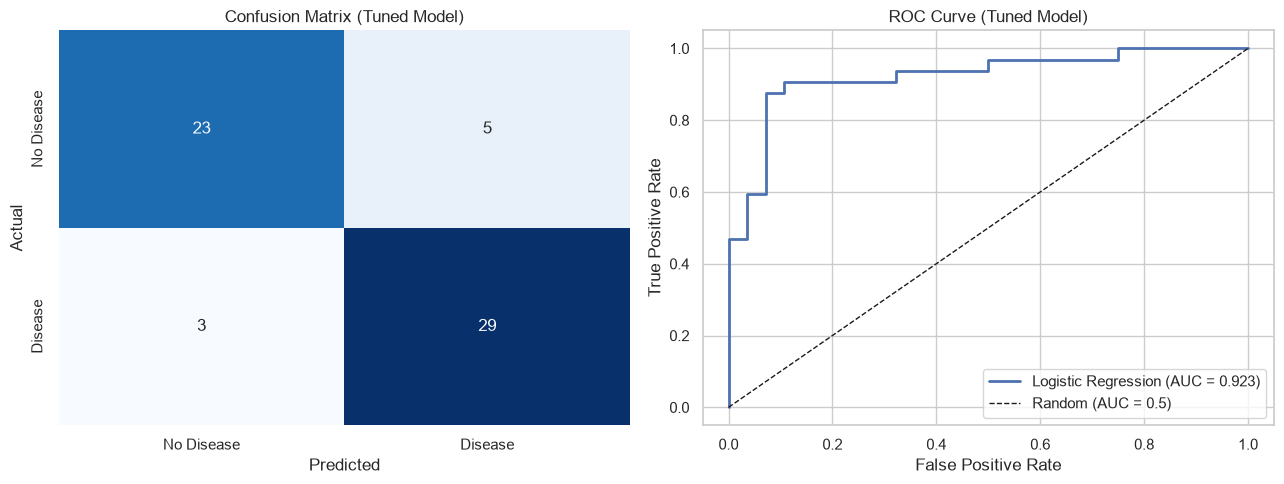

In [22]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Tuned Model)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'{best_name} (AUC = {roc_auc_score(y_test, y_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Tuned Model)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 10. Feature Importance

The tuned model ({best_name}) is used to explain which features drive predictions. For tree models we use `feature_importances_`; for linear models (like the best Logistic Regression) we use the **absolute coefficients** `|coef_|` - the larger the magnitude, the stronger the influence (positive/negative sign is shown separately).

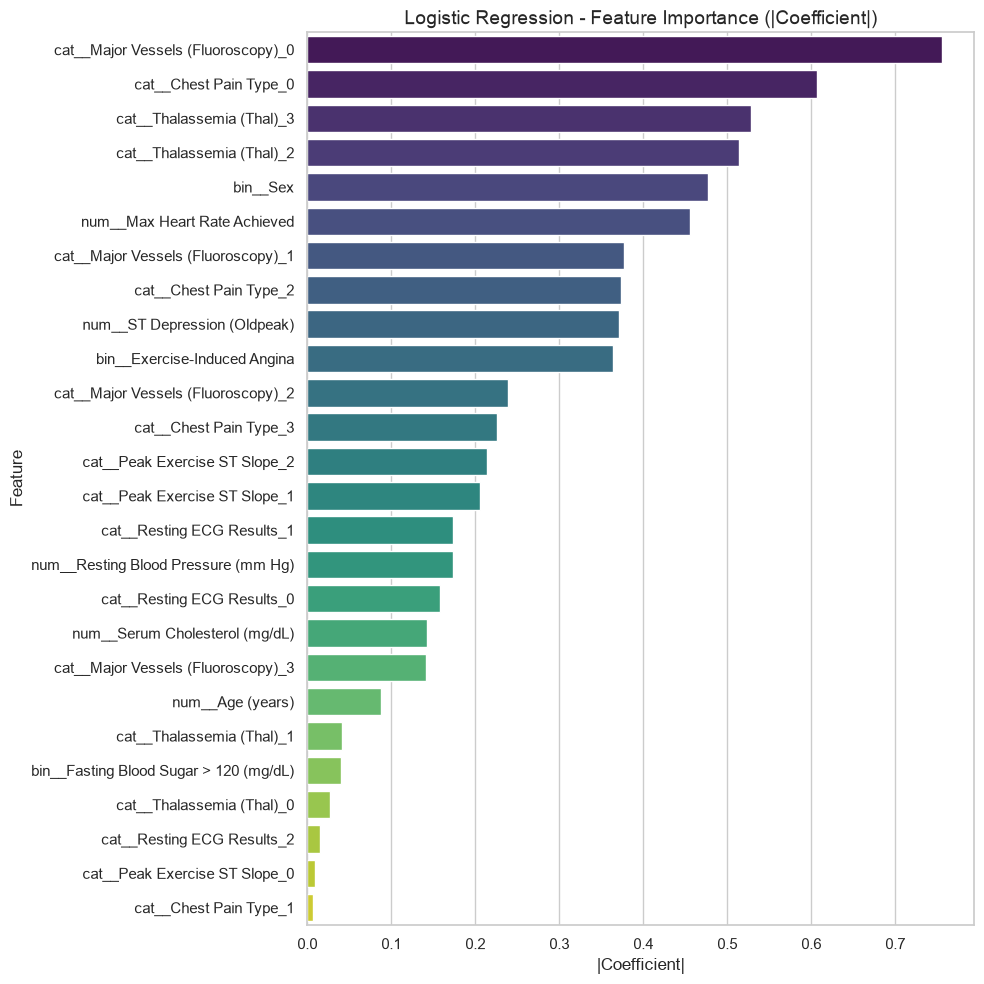

,Feature,|Coefficient|
18,cat__Major Vessels (Fluoroscopy)_0,0.755880
8,cat__Chest Pain Type_0,0.607011
25,cat__Thalassemia (Thal)_3,0.528272
24,cat__Thalassemia (Thal)_2,0.514018
5,bin__Sex,0.477065
3,num__Max Heart Rate Achieved,0.455223
19,cat__Major Vessels (Fluoroscopy)_1,0.376482
10,cat__Chest Pain Type_2,0.373433
4,num__ST Depression (Oldpeak),0.371429
7,bin__Exercise-Induced Angina,0.363625


In [23]:
clf_step = best_model.named_steps['clf']
feature_names = best_model.named_steps['preproc'].get_feature_names_out()

if hasattr(clf_step, 'feature_importances_'):
    importances = clf_step.feature_importances_
    imp_label = 'Importance'
else:
    importances = np.abs(clf_step.coef_).ravel()
    imp_label = '|Coefficient|'

fi_df = pd.DataFrame({'Feature': feature_names, imp_label: importances}).sort_values(imp_label, ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=fi_df, x=imp_label, y='Feature', palette='viridis')
plt.title(f'{best_name} - Feature Importance ({imp_label})', fontsize=14)
plt.tight_layout()
plt.show()
fi_df.head(15)

## 11. Cross-Validation on the Final Model

In [24]:
cv_scores = cross_val_score(best_model, X_train, y_train,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='roc_auc')
print(f'5-Fold CV ROC-AUC scores: {np.round(cv_scores, 4)}')
print(f'Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

5-Fold CV ROC-AUC scores: [0.9318 0.8916 0.8759 0.989  0.8945]
Mean CV AUC: 0.9166 (+/- 0.0406)


## 12. Save the Model & Scaler for Deployment

In [25]:
joblib.dump(best_model, 'heart_disease_model.pkl')
print('Saved: heart_disease_model.pkl')

scaler_step = best_model.named_steps['preproc'].named_transformers_['num']
joblib.dump(scaler_step, 'heart_disease_scaler.pkl')
print('Saved: heart_disease_scaler.pkl')

print(f'Model file size: {os.path.getsize("heart_disease_model.pkl") / 1024:.1f} KB')
print(f'Scaler file size: {os.path.getsize("heart_disease_scaler.pkl") / 1024:.1f} KB')
print('\nScaler (StandardScaler) - continuous columns it was fitted on:')
print(list(scaler_step.feature_names_in_))
print(f'Scaler mean: {scaler_step.mean_.round(3)}')
print(f'Scaler scale (std): {scaler_step.scale_.round(3)}')

Saved: heart_disease_model.pkl
Saved: heart_disease_scaler.pkl
Model file size: 4.9 KB
Scaler file size: 1.0 KB

Scaler (StandardScaler) - continuous columns it was fitted on:
['Age (years)', 'Resting Blood Pressure (mm Hg)', 'Serum Cholesterol (mg/dL)', 'Max Heart Rate Achieved', 'ST Depression (Oldpeak)']
Scaler mean: [ 54.353 131.134 247.479 149.929   1.036]
Scaler scale (std): [ 8.959 17.085 50.832 23.098  1.122]


## 13. Prediction on a New Patient (with confidence score)

In [26]:
sample = pd.DataFrame([{
    'Age (years)': 55, 'Sex': 1, 'Chest Pain Type': 0, 'Resting Blood Pressure (mm Hg)': 140,
    'Serum Cholesterol (mg/dL)': 250, 'Fasting Blood Sugar > 120 (mg/dL)': 0,
    'Resting ECG Results': 1, 'Max Heart Rate Achieved': 150, 'Exercise-Induced Angina': 0,
    'ST Depression (Oldpeak)': 1.0, 'Peak Exercise ST Slope': 2,
    'Major Vessels (Fluoroscopy)': 0, 'Thalassemia (Thal)': 3
}])

pred = best_model.predict(sample)[0]
prob_disease = best_model.predict_proba(sample)[0][1]

print(f'Prediction: {pred} -> {"Heart Disease" if pred == 1 else "No Heart Disease"}')
print(f'Confidence (probability of disease): {prob_disease:.4f} ({prob_disease * 100:.2f}%)')
print(f'Confidence (probability of NO disease): {1 - prob_disease:.4f} ({(1 - prob_disease) * 100:.2f}%)')

risk = 'HIGH' if prob_disease >= 0.6 else ('MEDIUM' if prob_disease >= 0.4 else 'LOW')
print(f'Risk level: {risk}')

Prediction: 0 -> No Heart Disease
Confidence (probability of disease): 0.4548 (45.48%)
Confidence (probability of NO disease): 0.5452 (54.52%)
Risk level: MEDIUM


## 14. Loading the Saved Model & Scaler Standalone

The scaler was extracted from the pipeline and saved separately, so you can also **scale raw continuous inputs yourself** before calling the model":

In [27]:
loaded_model = joblib.load('heart_disease_model.pkl')
loaded_scaler = joblib.load('heart_disease_scaler.pkl')

print('Load a single new patient and scale the continuous features manually:')
sample_cont = sample[cont_cols]
scaled_cont = loaded_scaler.transform(sample_cont)
print(pd.DataFrame(scaled_cont, columns=cont_cols))
print('\nThese scaled values are exactly what the pipeline feeds to the model '
      '(binary flags stay 0/1, categoricals are one-hot encoded inside the pipeline).')

Load a single new patient and scale the continuous features manually:
   Age (years)  Resting Blood Pressure (mm Hg)  Serum Cholesterol (mg/dL)  \
0     0.072225                        0.518923                   0.049595   

   Max Heart Rate Achieved  ST Depression (Oldpeak)  
0                 0.003092                -0.031839  

These scaled values are exactly what the pipeline feeds to the model (binary flags stay 0/1, categoricals are one-hot encoded inside the pipeline).


## 15. Conclusion

- Cleaned the dataset (dropped 723 duplicates and 18 invalid `ca = 4` rows).
- EDA showed `Chest Pain Type`, `Max Heart Rate Achieved`, `ST Depression (Oldpeak)`, `Exercise-Induced Angina`, `Peak Exercise ST Slope`, `Major Vessels (Fluoroscopy)`, `Thalassemia (Thal)` as the strongest predictors.
- Preprocessed with StandardScaler + OneHotEncoder inside a single sklearn pipeline.
- Compared 9 models; tuned the best with GridSearchCV (5-fold stratified CV).
- **Final model: tuned {best_name}** - strong ROC-AUC, accuracy ~0.8+ and saved as `heart_disease_model.pkl` for deployment.
- The **StandardScaler** is saved separately as `heart_disease_scaler.pkl` for manual preprocessing.
- The pipeline gives a confidence score (`predict_proba`) for every prediction.

## Appendix: Chest Pain Type (cp) Legend

**Chest Pain Type** (cp) takes **4 values (0-3)** in this dataset:

| cp | Type | Description |
|---|---|---|
| 0 | Typical angina | Classic exertional chest pain caused by reduced blood flow to the heart |
| 1 | Atypical angina | Chest pain that does not fit the classic angina pattern |
| 2 | Non-anginal pain | Chest pain unrelated to the heart (e.g. muscular, reflux) |
| 3 | Asymptomatic | No chest pain at all |

Note: the original UCI Cleveland file codes these as 1-4; this processed version stores 0-3.